## Data Analysis Project

DATA Cleaning Methods

1. Data Collection

-> Multiple Sources

-> Web Scraping

-> APIs                              
-> Databases

-> Surveys

All these stored amd provide **RAW DATA**

Now, Raw Data has various kinds of Problems:

-> Spelling Errors

-> Missing Values

-> Outliers

-> Duplicate Values

-> Incorrect Data Types, e.g., Date, Time

-> Inconsistent Formatting

So modelling and analysis get wrong if problems are not rectified...

So, DATA Cleaning is the process of detecting, correcting and handling errors in raw Data to make it suitable for analysis or modelling.

.

**Step 1: Data Collection and Inspection**

Type of data in each column.

Check for missing values, etc as in the above list

Check for Data Types

Inconsistencies

# **Techniques**

1-> Summary statistics

2-> Distribution Plot

3-> Information (.info() function -> data types, Null/Not Null, etc)

4-> Frequency Graph -> Categorical Data

5-> Visual Inspection

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("sample_data/messy_customer_sales_data.csv")
df

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
0,CUST4371,Paul Wilson,m,52.0,KOLKATA,2025-06-26,2025-05-17,26944.0,1.0,peckvictoria@example.com,2131107701,India
1,CUST5957,Jason Thomas,M,51.0 years,NaN,2021-02-17,2025-07-22,44152.0,2.0,owensanthony@example.com,1080761560,india
2,CUST3754,Brittney Martinez,F,62.0,hyderabad,2023-11-05,2024-12-08,31745.0,2.0,tara39@example.org,8981006345,India
3,CUST2934,Brenda Pierce,FEMALE,40.0,hyderabad,2022-03-13,2025-10-02,39674.0,1.0,berrynancy@example.org,8228064204,india
4,CUST5683,Matthew Carroll,f,41.0,CHENNAI,2024-04-05,2024-12-15,NaN,8.0,denise84@example.org,2665569480,India
...,...,...,...,...,...,...,...,...,...,...,...,...
10195,CUST10767,Robert Lewis,female,35.0 years,delhi,2020-12-08,2025-01-25,24167.0,9.0,barrycrane@example.net,5004696571,InDia
10196,NaN,Diane Evans,M,53.0,bangalore,2023-12-31,2025-05-07,11639.0,7.0,lisadennis@example.net,5200349941,IND
10197,CUST6315,Joshua Martinez,m,25.0,hyderabad,2022-02-15,2025-01-11,43832.0,2.0,kelli74@example.org,8147428496,India
10198,CUST4812,Sarah Miller,FEMALE,55.0,NaN,2021-03-16,2025-05-14,18827.0,10.0,dawn84@example.org,2987564247,InDia


In [ ]:
## info() functio  provide information about datatypes, null/not null, etc
df.info()
## it is observed that Age, Signup_Date, Last Purchase Date have wrong DataTypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10200 entries, 0 to 10199
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         9177 non-null   object 
 1   Name                10200 non-null  object 
 2   Gender              9174 non-null   object 
 3   Age                 9249 non-null   object 
 4   City                9184 non-null   object 
 5   Signup_Date         10200 non-null  object 
 6   Last_Purchase_Date  9188 non-null   object 
 7   Purchase_Amount     9179 non-null   float64
 8   Feedback_Score      9177 non-null   float64
 9   Email               10200 non-null  object 
 10  Phone_Number        10200 non-null  int64  
 11  Country             9468 non-null   object 
dtypes: float64(2), int64(1), object(9)
memory usage: 956.4+ KB


In [ ]:
## describe() function provide statistic analysis of the dataset.
## in the below stats it is found that minimum purchase value is -500 which is not possible, and also the maximum value is far more than 75% so these are outliers

df.describe().round()

,Purchase_Amount,Feedback_Score,Phone_Number
count,9179.0,9177.0,1.020000e+04
mean,29090.0,5.0,4.979974e+09
std,208697.0,3.0,2.902593e+09
min,-500.0,1.0,9.208990e+05
25%,12295.0,3.0,2.449157e+09
50%,24330.0,5.0,4.988639e+09
75%,37130.0,8.0,7.510448e+09
max,9999999.0,10.0,9.994402e+09


In [ ]:
## Checking for missing values
Sum_Null = df.isnull().sum() ## -> Provide sum of missing places in total for each column
print(Sum_Null)
Percent_Null = df.isnull().sum()/ len(df) * 100 ## -> Provide percentage of missing places in total for each column out of totall 100%
print("\nPercentage of missing values in dataset for each column\n")
print(Percent_Null)

Customer_ID           1023
Name                     0
Gender                1026
Age                    951
City                  1016
Signup_Date              0
Last_Purchase_Date    1012
Purchase_Amount       1021
Feedback_Score        1023
Email                    0
Phone_Number             0
Country                732
dtype: int64

Percentage of missing values in dataset for each column

Customer_ID           10.029412
Name                   0.000000
Gender                10.058824
Age                    9.323529
City                   9.960784
Signup_Date            0.000000
Last_Purchase_Date     9.921569
Purchase_Amount       10.009804
Feedback_Score        10.029412
Email                  0.000000
Phone_Number           0.000000
Country                7.176471
dtype: float64


In [ ]:
df.shape ## so out of 10200 records -> 10% i.e. 1020 records are not found with Customer ID.


(10200, 12)

In [ ]:
## customer ID is unique -> Primary Value
df.dropna().shape
## after removing all the missing values -> Shape of the data reduces to 4528 records thus, around 60% data get loss.

## So, Data Drop krna is not Good Method to handle it.

(4528, 12)

In [ ]:
## Now Lets check for total duplicated values
duplicated_rows = df[df.duplicated()].shape
print(duplicated_rows)
## So, (15,12) -> 15 rows have duplicated values and 12 columns have duplicated values

(15, 12)


In [ ]:
## Some of the records may not get count in the duplicated rows
## Because May be some of the columns data donot match
## E.g.
df['Customer_ID'].value_counts() ## provided number of times customer_id repeats

## here, it is found that some of the customer ids are repeated which is wrong and they donot get counted in duplication
df['Customer_ID'].value_counts().head(10)

,count
Customer_ID,
CUST10800,2
CUST6588,2
CUST9062,2
CUST1852,2
CUST5472,2
CUST4160,2
CUST5019,2
CUST6288,2
CUST8174,2


In [ ]:
df[df['Customer_ID'] == 'CUST10800']

## as below, Genders column for same customer have different inputs (F or female) due to which row are repeated but not counted

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
3986,CUST10800,Kevin Clark,F,52.0,Bangalore,2021-06-29,2025-09-12,34914.0,10.0,sandycarey@example.net,2719399414,India
10103,CUST10800,Kevin Clark,female,52.0,Bangalore,2021-06-29,2025-09-12,34914.0,10.0,sandycarey@example.net,2719399414,india


In [ ]:
for cols in df.columns:
  if df[cols].nunique() < 20:
    print(df[cols].value_counts())
    print('---'*15)

Gender
f         1184
M         1171
m         1163
F         1157
MALE      1131
female    1128
male      1121
FEMALE    1119
Name: count, dtype: int64
---------------------------------------------
City
Kolkata       820
Mumbai        812
Chennai       784
Bangalore     773
Hyderabad     770
Delhi         763
CHENNAI       404
KOLKATA       395
MUMBAI        393
hyderabad     384
bangalore     383
DELHI         378
delhi         369
BANGALORE     363
HYDERABAD     360
mumbai        352
chennai       343
kolkata       338
Name: count, dtype: int64
---------------------------------------------
Feedback_Score
2.0     952
4.0     947
7.0     938
6.0     927
3.0     913
8.0     912
1.0     907
9.0     903
10.0    901
5.0     877
Name: count, dtype: int64
---------------------------------------------
Country
India    7132
IND       793
india     772
InDia     771
Name: count, dtype: int64
---------------------------------------------


# **Handling Missing Values**

In [ ]:
df.dropna(subset='Customer_ID', inplace=True)
df.head(10)

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
0,CUST4371,Paul Wilson,m,52.0,KOLKATA,2025-06-26,2025-05-17,26944.0,1.0,peckvictoria@example.com,2131107701,India
1,CUST5957,Jason Thomas,M,51.0 years,NaN,2021-02-17,2025-07-22,44152.0,2.0,owensanthony@example.com,1080761560,india
2,CUST3754,Brittney Martinez,F,62.0,hyderabad,2023-11-05,2024-12-08,31745.0,2.0,tara39@example.org,8981006345,India
3,CUST2934,Brenda Pierce,FEMALE,40.0,hyderabad,2022-03-13,2025-10-02,39674.0,1.0,berrynancy@example.org,8228064204,india
4,CUST5683,Matthew Carroll,f,41.0,CHENNAI,2024-04-05,2024-12-15,NaN,8.0,denise84@example.org,2665569480,India
5,CUST1516,William Day,F,NaN,kolkata,2021-05-02,2025-06-09,27663.0,10.0,richard34@example.net,9463089646,NaN
6,CUST3651,Laura Vincent,male,18.0,BANGALORE,2024-06-16,2025-04-25,NaN,3.0,ymiranda@example.net,6917110630,India
7,CUST10438,Timothy Dunlap,F,43.0 years,Hyderabad,2025-03-16,2025-04-25,18355.0,9.0,christopheranderson@example.net,9981404428,india
8,CUST5189,Sabrina Miller,F,40.0 years,CHENNAI,2025-07-07,2024-10-30,NaN,10.0,shepardcolton@example.net,6233441825,India
9,CUST8237,Mr. Thomas Garcia,F,26.0,NaN,2025-05-24,2024-10-15,28206.0,NaN,heidimartinez@example.org,1225343854,InDia


In [ ]:
df.shape

(9177, 12)

In [ ]:
print(df.isnull().sum())

print("--" * 50)
print(df.isnull()['Customer_ID'].sum())


Customer_ID             0
Name                    0
Gender                934
Age                   859
City                  918
Signup_Date             0
Last_Purchase_Date    914
Purchase_Amount       927
Feedback_Score        905
Email                   0
Phone_Number            0
Country               664
dtype: int64
----------------------------------------------------------------------------------------------------
0


In [ ]:
df['Age'].unique()

array(['52.0', '51.0 years', '62.0', '40.0', '41.0', nan, '18.0',
       '43.0 years', '40.0 years', '26.0', '32.0', '22.0', '59.0', '65.0',
       '61.0', '31.0', '54.0 years', '55.0', '69.0', '61.0 years', '24.0',
       '63.0', '19.0', '50.0', '56.0', '36.0', '68.0', '43.0', '38.0',
       '27.0', '57.0 years', '23.0', '25.0', '66.0', '28.0', '30.0',
       '46.0', '48.0', '20.0', '37.0', '67.0', '51.0', '35.0', '58.0',
       '29.0', 'nan years', '39.0', '49.0', '47.0', '42.0', '44.0',
       '64.0', '53.0', '60.0', '59.0 years', '45.0', '21.0', '34.0',
       '54.0', '48.0 years', '46.0 years', '33.0', '57.0', '30.0 years',
       '58.0 years', '35.0 years', '34.0 years', '69.0 years', '250',
       '19.0 years', '27.0 years', '53.0 years', '65.0 years',
       '66.0 years', '44.0 years', '49.0 years', '25.0 years',
       '23.0 years', '62.0 years', '41.0 years', '33.0 years',
       '28.0 years', '22.0 years', '20.0 years', '42.0 years',
       '45.0 years', '3', '63.0 years', '

In [ ]:
df['Updated_Age'] = df['Age'].str.split('.0 ', n=0, expand=True)[0]
df['Age'] = df['Updated_Age']


In [ ]:
df['Age']

,Age
0,52.0
1,51
2,62.0
3,40.0
4,41.0
...,...
10194,40.0
10195,35
10197,25.0
10198,55.0


In [ ]:
df.head()


,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country,Updated_Age
0,CUST4371,Paul Wilson,m,52.0,KOLKATA,2025-06-26,2025-05-17,26944.0,1.0,peckvictoria@example.com,2131107701,India,52.0
1,CUST5957,Jason Thomas,M,51,NaN,2021-02-17,2025-07-22,44152.0,2.0,owensanthony@example.com,1080761560,india,51
2,CUST3754,Brittney Martinez,F,62.0,hyderabad,2023-11-05,2024-12-08,31745.0,2.0,tara39@example.org,8981006345,India,62.0
3,CUST2934,Brenda Pierce,FEMALE,40.0,hyderabad,2022-03-13,2025-10-02,39674.0,1.0,berrynancy@example.org,8228064204,india,40.0
4,CUST5683,Matthew Carroll,f,41.0,CHENNAI,2024-04-05,2024-12-15,NaN,8.0,denise84@example.org,2665569480,India,41.0


In [ ]:
df['Age'].unique()

array(['52.0', '51', '62.0', '40.0', '41.0', nan, '18.0', '43', '40',
       '26.0', '32.0', '22.0', '59.0', '65.0', '61.0', '31.0', '54',
       '55.0', '69.0', '61', '24.0', '63.0', '19.0', '50.0', '56.0',
       '36.0', '68.0', '43.0', '38.0', '27.0', '57', '23.0', '25.0',
       '66.0', '28.0', '30.0', '46.0', '48.0', '20.0', '37.0', '67.0',
       '51.0', '35.0', '58.0', '29.0', 'nan years', '39.0', '49.0',
       '47.0', '42.0', '44.0', '64.0', '53.0', '60.0', '59', '45.0',
       '21.0', '34.0', '54.0', '48', '46', '33.0', '57.0', '30', '58',
       '35', '34', '69', '250', '19', '27', '53', '65', '66', '44', '49',
       '25', '23', '62', '41', '33', '28', '22', '20', '42', '45', '3',
       '63', '37', '38', '55', '18', '36', '67', '29', '39', '31', '47',
       '52', '-10', '60', '24', '26', '21', '64', '50', '68', '32', '56'],
      dtype=object)

In [ ]:
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['Age']

,Age
0,52.0
1,51.0
2,62.0
3,40.0
4,41.0
...,...
10194,40.0
10195,35.0
10197,25.0
10198,55.0


In [ ]:
age_median = int(df['Age'].dropna().astype('int64').median())
print(age_median)


43


In [ ]:
df['Age'].fillna(age_median, inplace=True)

In [ ]:
df['Age'].unique()

array([ 52.,  51.,  62.,  40.,  41.,  43.,  18.,  26.,  32.,  22.,  59.,
        65.,  61.,  31.,  54.,  55.,  69.,  24.,  63.,  19.,  50.,  56.,
        36.,  68.,  38.,  27.,  57.,  23.,  25.,  66.,  28.,  30.,  46.,
        48.,  20.,  37.,  67.,  35.,  58.,  29.,  39.,  49.,  47.,  42.,
        44.,  64.,  53.,  60.,  45.,  21.,  34.,  33., 250.,   3., -10.])

In [ ]:
df['Age'].unique()

array([ 52.,  51.,  62.,  40.,  41.,  43.,  18.,  26.,  32.,  22.,  59.,
        65.,  61.,  31.,  54.,  55.,  69.,  24.,  63.,  19.,  50.,  56.,
        36.,  68.,  38.,  27.,  57.,  23.,  25.,  66.,  28.,  30.,  46.,
        48.,  20.,  37.,  67.,  35.,  58.,  29.,  39.,  49.,  47.,  42.,
        44.,  64.,  53.,  60.,  45.,  21.,  34.,  33., 250.,   3., -10.])

In [ ]:
df['Age'].replace(-10, age_median)
df['Age'].unique()

array([ 52.,  51.,  62.,  40.,  41.,  43.,  18.,  26.,  32.,  22.,  59.,
        65.,  61.,  31.,  54.,  55.,  69.,  24.,  63.,  19.,  50.,  56.,
        36.,  68.,  38.,  27.,  57.,  23.,  25.,  66.,  28.,  30.,  46.,
        48.,  20.,  37.,  67.,  35.,  58.,  29.,  39.,  49.,  47.,  42.,
        44.,  64.,  53.,  60.,  45.,  21.,  34.,  33., 250.,   3., -10.])

In [ ]:
print(df.isnull().sum())

Customer_ID             0
Name                    0
Gender                934
Age                     0
City                  918
Signup_Date             0
Last_Purchase_Date    914
Purchase_Amount       927
Feedback_Score        905
Email                   0
Phone_Number            0
Country               664
Updated_Age           859
dtype: int64


In [ ]:
Purchase_median = int(df['Purchase_Amount'].dropna().astype('int64').median())
df['Purchase_Amount'].fillna(Purchase_median, inplace=True)
print(df.isnull().sum())

Customer_ID             0
Name                    0
Gender                934
Age                     0
City                  918
Signup_Date             0
Last_Purchase_Date    914
Purchase_Amount         0
Feedback_Score        905
Email                   0
Phone_Number            0
Country               664
Updated_Age           859
dtype: int64


/tmp/ipython-input-2488644152.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Purchase_Amount'].fillna(Purchase_median, inplace=True)


In [ ]:
df['Feedback_Score'].fillna(df['Feedback_Score'].mode()[0], inplace=True)
print(df.isnull().sum())

Customer_ID             0
Name                    0
Gender                934
Age                     0
City                  918
Signup_Date             0
Last_Purchase_Date    914
Purchase_Amount         0
Feedback_Score          0
Email                   0
Phone_Number            0
Country               664
Updated_Age           859
dtype: int64


/tmp/ipython-input-3938393289.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Feedback_Score'].fillna(df['Feedback_Score'].mode()[0], inplace=True)


In [ ]:
df.drop('Updated_Age', axis=1, inplace=True)
df

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
0,CUST4371,Paul Wilson,m,52.0,KOLKATA,2025-06-26,2025-05-17,26944.0,1.0,peckvictoria@example.com,2131107701,India
1,CUST5957,Jason Thomas,M,51.0,NaN,2021-02-17,2025-07-22,44152.0,2.0,owensanthony@example.com,1080761560,india
2,CUST3754,Brittney Martinez,F,62.0,hyderabad,2023-11-05,2024-12-08,31745.0,2.0,tara39@example.org,8981006345,India
3,CUST2934,Brenda Pierce,FEMALE,40.0,hyderabad,2022-03-13,2025-10-02,39674.0,1.0,berrynancy@example.org,8228064204,india
4,CUST5683,Matthew Carroll,f,41.0,CHENNAI,2024-04-05,2024-12-15,24268.0,8.0,denise84@example.org,2665569480,India
...,...,...,...,...,...,...,...,...,...,...,...,...
10194,CUST6146,Cody Thompson,f,40.0,NaN,2024-08-21,2024-10-26,35101.0,1.0,mitchellrivera@example.net,6380823112,India
10195,CUST10767,Robert Lewis,female,35.0,delhi,2020-12-08,2025-01-25,24167.0,9.0,barrycrane@example.net,5004696571,InDia
10197,CUST6315,Joshua Martinez,m,25.0,hyderabad,2022-02-15,2025-01-11,43832.0,2.0,kelli74@example.org,8147428496,India
10198,CUST4812,Sarah Miller,FEMALE,55.0,NaN,2021-03-16,2025-05-14,18827.0,10.0,dawn84@example.org,2987564247,InDia


In [ ]:
print(df.isnull().sum())

Customer_ID             0
Name                    0
Gender                934
Age                     0
City                  918
Signup_Date             0
Last_Purchase_Date    914
Purchase_Amount         0
Feedback_Score          0
Email                   0
Phone_Number            0
Country               664
dtype: int64


In [ ]:
for cols in ['Gender', 'City', 'Country']:
  df[cols].fillna(df[cols].mode()[0], inplace=True)

/tmp/ipython-input-1105141755.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[cols].fillna(df[cols].mode()[0], inplace=True)


In [ ]:
print(df.isnull().sum())

Customer_ID             0
Name                    0
Gender                  0
Age                     0
City                    0
Signup_Date             0
Last_Purchase_Date    914
Purchase_Amount         0
Feedback_Score          0
Email                   0
Phone_Number            0
Country                 0
dtype: int64


In [ ]:
df['Last_Purchase_Date'].ffill(inplace=True)
df.isnull().sum()

/tmp/ipython-input-3848057063.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Last_Purchase_Date'].ffill(inplace=True)


,0
Customer_ID,0
Name,0
Gender,0
Age,0
City,0
Signup_Date,0
Last_Purchase_Date,0
Purchase_Amount,0
Feedback_Score,0
Email,0


# **Fixing Inconsistent Formatting**


*   Different types of Values are inputted in same Column E.g. 'M', 'm', 'F', 'f', 'Male', 'Female'

*   Replace into all the values in Lower Case -> Some cases gets eliminated

*   Extra Spaces if any added up -> May include into different formatting categories





In [ ]:
## Unique() Function is used to identify all the unique values present in the column "Gender"
df['Gender'].unique()

array(['m ', 'M', 'F', 'FEMALE', 'f ', 'male', 'MALE', 'female'],
      dtype=object)

In [ ]:
## df.str.title() -> It is the function used to convert all the values into Title Case Format
## E.g. M->M, m->M, f->F, F->F, female -> Female, male -> Male
## df.str.strip() Function is used to remove leading and trailing characters, primarily whitespace, from each string in a Series or Index

df['Gender'] = df['Gender'].str.title().str.strip()

In [ ]:
## Gender gets reduces to four types -> M, F, Female, Male
df['Gender'].unique()

array(['M', 'F', 'Female', 'Male'], dtype=object)

In [ ]:
## Now, We need to replace pending column values into common ones
## replace() Function is used to replace the values with New One...
## E.g. ['M', 'F'] -> ['Male', 'Female']

df['Gender'].replace(['M','F'], ['Male', 'Female'], inplace=True)

/tmp/ipython-input-2165030527.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].replace(['M','F'], ['Male', 'Female'], inplace=True)


In [ ]:
## Now, all the categories get converted into -> Male or Female
df['Gender'].unique()

array(['Male', 'Female'], dtype=object)

In [ ]:
## Similarly, for City column convert into Title Format Case and all the white spaces are removed.
df['City'] = df['City'].str.title().str.strip()
df['City'].unique()

array(['Kolkata', 'Hyderabad', 'Chennai', 'Bangalore', 'Mumbai', 'Delhi'],
      dtype=object)

In [ ]:
## Similarly, for the Country column, convert into Title Format Case and all the white spaces are removed.

df['Country'] = df['Country'].str.title().str.strip()
df['Country'].unique()

array(['India', 'Ind'], dtype=object)

In [ ]:
## Replace all the Old Values into New Values...

df['Country'].replace('Ind', 'India', inplace=True)

/tmp/ipython-input-1368971137.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Country'].replace('Ind', 'India', inplace=True)


In [ ]:
df.head()

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
0,CUST4371,Paul Wilson,Male,52.0,Kolkata,2025-06-26,2025-05-17,26944.0,1.0,peckvictoria@example.com,2131107701,India
1,CUST5957,Jason Thomas,Male,51.0,Kolkata,2021-02-17,2025-07-22,44152.0,2.0,owensanthony@example.com,1080761560,India
2,CUST3754,Brittney Martinez,Female,62.0,Hyderabad,2023-11-05,2024-12-08,31745.0,2.0,tara39@example.org,8981006345,India
3,CUST2934,Brenda Pierce,Female,40.0,Hyderabad,2022-03-13,2025-10-02,39674.0,1.0,berrynancy@example.org,8228064204,India
4,CUST5683,Matthew Carroll,Female,41.0,Chennai,2024-04-05,2024-12-15,24268.0,8.0,denise84@example.org,2665569480,India


In [ ]:
## For Loop is used to find the number of Unique Values in each column category
## and frequency of each category available using value_counts() function.

for cols in df.columns:
  if df[cols].nunique() < 20:
    print(df[cols].value_counts())
    print('---'*15)

Gender
Male      5074
Female    4103
Name: count, dtype: int64
---------------------------------------------
City
Kolkata      2303
Mumbai       1386
Chennai      1380
Delhi        1376
Bangalore    1367
Hyderabad    1365
Name: count, dtype: int64
---------------------------------------------
Feedback_Score
2.0     1763
7.0      851
4.0      847
8.0      842
6.0      830
3.0      820
1.0      816
9.0      814
10.0     800
5.0      794
Name: count, dtype: int64
---------------------------------------------
Country
India    9177
Name: count, dtype: int64
---------------------------------------------


# **Handling Duplicates**

*   Remove Duplicate Records
*   Check for Primary Keys
*   Remove near Duplicate Values






In [ ]:
## After formatting change, we get an increment in the duplicate values in total to 163
df[df.duplicated()].shape

(163, 12)

In [ ]:
## Remove all the duplicated values using drop_duplicates() Function

df.drop_duplicates(inplace = True)

In [ ]:
## All the duplicate values get removed as shown below
df[df.duplicated()].shape

(0, 12)

In [ ]:
## Still, some of the Customer_IDs have two records (means an issue in Data feed)
df['Customer_ID'].value_counts()

,count
Customer_ID,
CUST6069,2
CUST9950,2
CUST7652,2
CUST5341,2
CUST2510,2
...,...
CUST6618,1
CUST2244,1
CUST6807,1


In [ ]:
df[df['Customer_ID'] == 'CUST2510']

## on checking it is found that Last_Purchase_Date is different in both the records...
## We need to handle all these records

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
1914,CUST2510,Henry Taylor,Female,29.0,Bangalore,2021-06-09,2025-06-14,24268.0,2.0,woodwilliam@example.com,6090100995,India
2242,CUST2510,Henry Taylor,Female,29.0,Bangalore,2021-06-09,2024-10-23,24268.0,2.0,woodwilliam@example.com,6090100995,India


In [ ]:
## Remove one of the entries in these records
## subset attribute need "Column_name"
## keep attribute let you to choose which duplicate value you want in the row -> second one is removed.

df.drop_duplicates(subset = ['Customer_ID'], keep = 'first', inplace = True)

In [ ]:
## Fourteen Rows are removed after deleting repeated customer ID records.

df.shape

(9000, 12)

In [ ]:
## checking the records... for Customer_ID = 'CUST2510'
df[df['Customer_ID'] == 'CUST2510']

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
1914,CUST2510,Henry Taylor,Female,29.0,Bangalore,2021-06-09,2025-06-14,24268.0,2.0,woodwilliam@example.com,6090100995,India


# **Correcting Data Types**

*   Numeric Values -> Int64 or Float64
*   Categorical -> Object
*   Date Time Data -> Date Time





In [ ]:
## checking of Data Types of Age column -> Float64 using dtypes Method
df['Age'].dtypes

dtype('float64')

In [ ]:
## Change the Data Type to int64 using astype() Function
df['Age'] = df['Age'].astype('int64') ## change into Int

In [ ]:
df['Age'].info()

<class 'pandas.core.series.Series'>
Index: 9000 entries, 0 to 10198
Series name: Age
Non-Null Count  Dtype
--------------  -----
9000 non-null   int64
dtypes: int64(1)
memory usage: 140.6 KB


In [ ]:
df['Age']

,Age
0,52
1,51
2,62
3,40
4,41
...,...
10193,26
10194,40
10195,35
10197,25


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9000 entries, 0 to 10198
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         9000 non-null   object 
 1   Name                9000 non-null   object 
 2   Gender              9000 non-null   object 
 3   Age                 9000 non-null   int64  
 4   City                9000 non-null   object 
 5   Signup_Date         9000 non-null   object 
 6   Last_Purchase_Date  9000 non-null   object 
 7   Purchase_Amount     9000 non-null   float64
 8   Feedback_Score      9000 non-null   float64
 9   Email               9000 non-null   object 
 10  Phone_Number        9000 non-null   int64  
 11  Country             9000 non-null   object 
dtypes: float64(2), int64(2), object(8)
memory usage: 914.1+ KB


In [ ]:
df['Signup_Date'] = pd.to_datetime(df['Signup_Date'])
df['Last_Purchase_Date'] = pd.to_datetime(df['Last_Purchase_Date'])

In [ ]:
df['Signup_Date'].info()
print('---'*15)
df['Last_Purchase_Date'].info()

<class 'pandas.core.series.Series'>
Index: 9000 entries, 0 to 10198
Series name: Signup_Date
Non-Null Count  Dtype         
--------------  -----         
9000 non-null   datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 140.6 KB
---------------------------------------------
<class 'pandas.core.series.Series'>
Index: 9000 entries, 0 to 10198
Series name: Last_Purchase_Date
Non-Null Count  Dtype         
--------------  -----         
9000 non-null   datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 140.6 KB


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9000 entries, 0 to 10198
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Customer_ID         9000 non-null   object        
 1   Name                9000 non-null   object        
 2   Gender              9000 non-null   object        
 3   Age                 9000 non-null   int64         
 4   City                9000 non-null   object        
 5   Signup_Date         9000 non-null   datetime64[ns]
 6   Last_Purchase_Date  9000 non-null   datetime64[ns]
 7   Purchase_Amount     9000 non-null   float64       
 8   Feedback_Score      9000 non-null   float64       
 9   Email               9000 non-null   object        
 10  Phone_Number        9000 non-null   int64         
 11  Country             9000 non-null   object        
dtypes: datetime64[ns](2), float64(2), int64(2), object(6)
memory usage: 914.1+ KB


# **Handling Outliers**

*   Genuine Outliers
*   Errors E.g. Purchase amount in Negative, Age is 250 or Neg.



In [ ]:
IQR_Age = (df['Age'].quantile(0.75)) - (df['Age'].quantile(0.25))
print(IQR_Age)

23.0


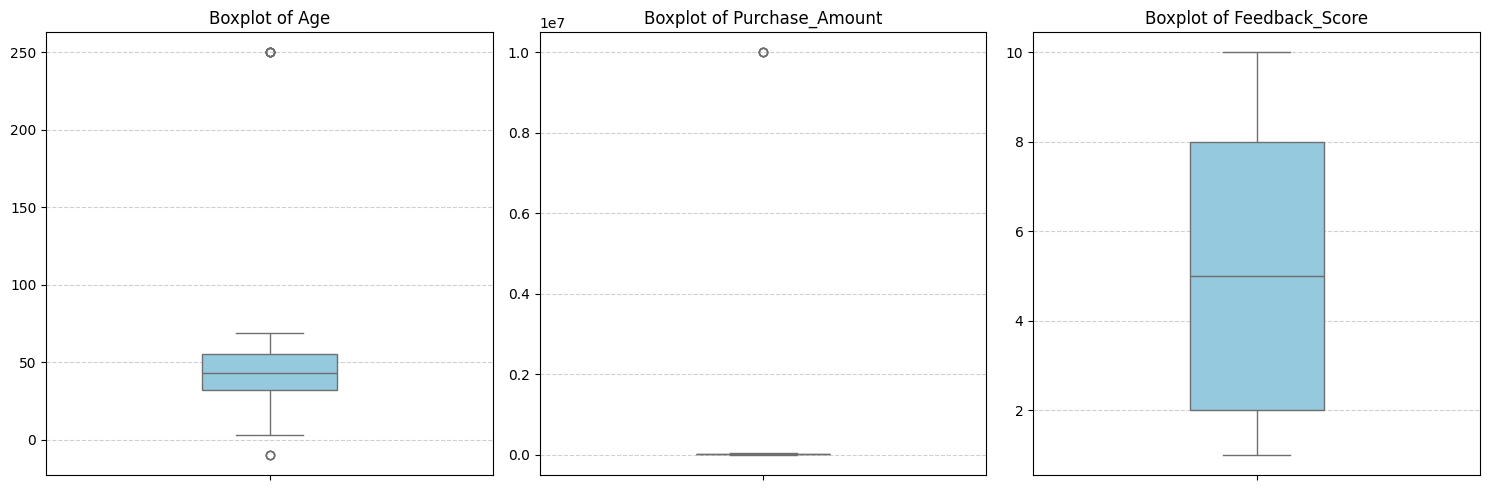

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ['Age', 'Purchase_Amount', 'Feedback_Score']

plt.figure(figsize=(15,5))
for i, cols in enumerate(cols, 1):
  plt.subplot(1,3,i)
  sns.boxplot(y=df[cols], color='skyblue', width=0.3)
  plt.title(f'Boxplot of {cols}', fontsize=12)
  plt.ylabel('')
  plt.grid(axis = 'y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


In [ ]:
from scipy import stats

In [ ]:
import numpy as np
z_scores = np.abs(stats.zscore(df[['Age', 'Purchase_Amount']]))
df_clean = df[~(z_scores>3).any(axis=1)]
df_clean.shape

(8986, 12)

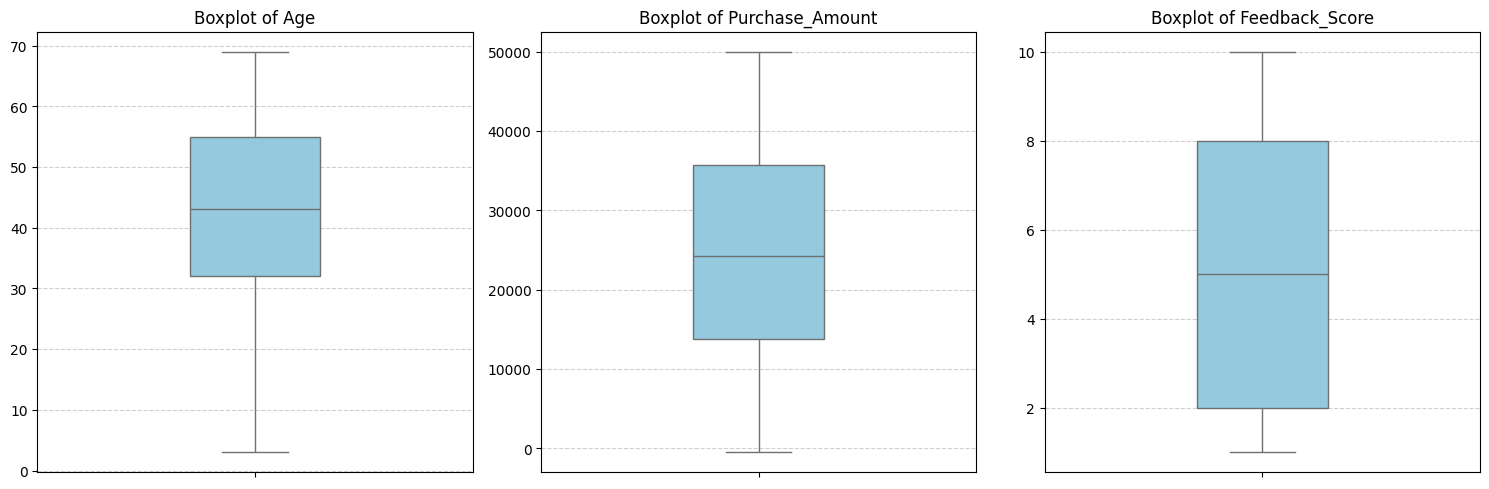

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ['Age', 'Purchase_Amount', 'Feedback_Score']

plt.figure(figsize=(15,5))
for i, cols in enumerate(cols, 1):
  plt.subplot(1,3,i)
  sns.boxplot(y=df_clean[cols], color='skyblue', width=0.3)
  plt.title(f'Boxplot of {cols}', fontsize=12)
  plt.ylabel('')
  plt.grid(axis = 'y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


In [ ]:
df=df_clean
df.shape

(8986, 12)

In [ ]:
df.head()

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
0,CUST4371,Paul Wilson,Male,52,Kolkata,2025-06-26,2025-05-17,26944.0,1.0,peckvictoria@example.com,2131107701,India
1,CUST5957,Jason Thomas,Male,51,Kolkata,2021-02-17,2025-07-22,44152.0,2.0,owensanthony@example.com,1080761560,India
2,CUST3754,Brittney Martinez,Female,62,Hyderabad,2023-11-05,2024-12-08,31745.0,2.0,tara39@example.org,8981006345,India
3,CUST2934,Brenda Pierce,Female,40,Hyderabad,2022-03-13,2025-10-02,39674.0,1.0,berrynancy@example.org,8228064204,India
4,CUST5683,Matthew Carroll,Female,41,Chennai,2024-04-05,2024-12-15,24268.0,8.0,denise84@example.org,2665569480,India


In [ ]:
df.to_csv('Final_Cleaned_Customer_sales.csv')

In [ ]:
df_new = pd.read_csv('Final_Cleaned_Customer_sales.csv')

In [ ]:
df_new.drop('Unnamed: 0', axis=1, inplace=True)
df_new

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
0,CUST4371,Paul Wilson,Male,52,Kolkata,2025-06-26,2025-05-17,26944.0,1.0,peckvictoria@example.com,2131107701,India
1,CUST5957,Jason Thomas,Male,51,Kolkata,2021-02-17,2025-07-22,44152.0,2.0,owensanthony@example.com,1080761560,India
2,CUST3754,Brittney Martinez,Female,62,Hyderabad,2023-11-05,2024-12-08,31745.0,2.0,tara39@example.org,8981006345,India
3,CUST2934,Brenda Pierce,Female,40,Hyderabad,2022-03-13,2025-10-02,39674.0,1.0,berrynancy@example.org,8228064204,India
4,CUST5683,Matthew Carroll,Female,41,Chennai,2024-04-05,2024-12-15,24268.0,8.0,denise84@example.org,2665569480,India
...,...,...,...,...,...,...,...,...,...,...,...,...
8981,CUST6352,Isaiah Terry,Female,26,Kolkata,2023-03-04,2025-06-30,43655.0,6.0,lopezleonard@example.net,7694723210,India
8982,CUST6146,Cody Thompson,Female,40,Kolkata,2024-08-21,2024-10-26,35101.0,1.0,mitchellrivera@example.net,6380823112,India
8983,CUST10767,Robert Lewis,Female,35,Delhi,2020-12-08,2025-01-25,24167.0,9.0,barrycrane@example.net,5004696571,India
8984,CUST6315,Joshua Martinez,Male,25,Hyderabad,2022-02-15,2025-01-11,43832.0,2.0,kelli74@example.org,8147428496,India
